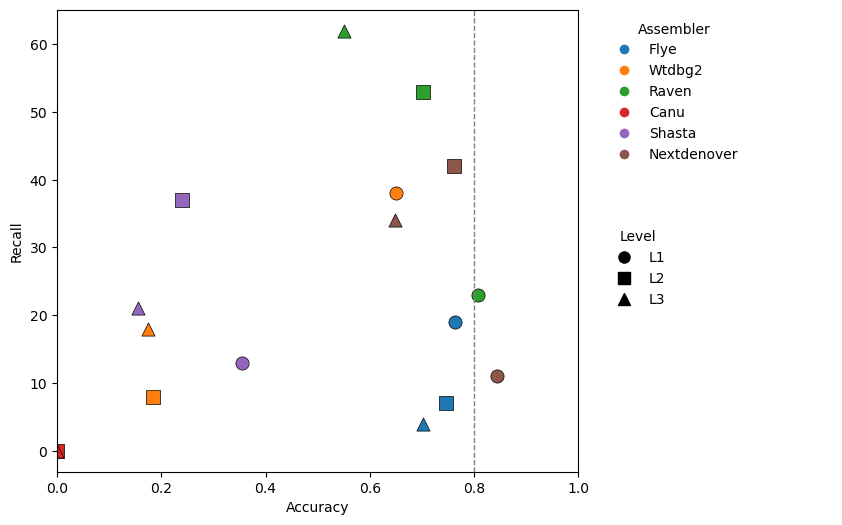

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
######v1
df = pd.read_csv("/Users/ppxinyi/Documents/Assembly_review/30xL1-L3/Accurcy_recall_plot.csv")
df[["tool","level"]] = df["ID"].str.split("_", expand=True)
df["level"] = pd.Categorical(df["level"], categories=["l1","l2","l3"], ordered=True)

tools = list(df["tool"].unique())
colors = dict(zip(tools, plt.cm.tab10.colors[:len(tools)]))
marker_map = {"l1": "o", "l2": "s", "l3": "^"}


fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1, 0.45], wspace=0.05)
ax = fig.add_subplot(gs[0, 0])
ax_leg = fig.add_subplot(gs[0, 1])
ax_leg.axis("off")  


for tool, sub in df.groupby("tool"):
    for _, row in sub.iterrows():
        ax.scatter(row["Accuracy"], row["Recall"],
                   color=colors[tool],
                   marker=marker_map[row["level"]],
                   s=90,
                   edgecolor="black",
                   linewidth=0.5)


ax.axvline(0.8, linestyle="--", linewidth=1, color="gray")

ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy")
ax.set_ylabel("Recall")


tool_handles = [
    Line2D([0],[0], marker='o', color='w', label=tool,
           markerfacecolor=colors[tool], markersize=8)
    for tool in tools
]
level_handles = [
    Line2D([0],[0], marker=marker_map[l], color='black',
           linestyle='None', label=l.upper(), markersize=8)
    for l in ["l1","l2","l3"]
]


leg1 = ax_leg.legend(handles=tool_handles, title="Assembler",
                     loc="upper left", frameon=False)
ax_leg.add_artist(leg1)

ax_leg.legend(handles=level_handles, title="Level",
              loc="upper left", bbox_to_anchor=(0, 0.55), frameon=False)


fig.savefig("/Users/ppxinyi/Documents/Assembly_review/30xL1-L3/main_figure/WGSAccuracy_Recall_main.pdf", dpi=600)
fig.savefig("/Users/ppxinyi/Documents/Assembly_review/30xL1-L3/main_figure/WGSAccuracy_Recall_main.png", dpi=600)
plt.show()


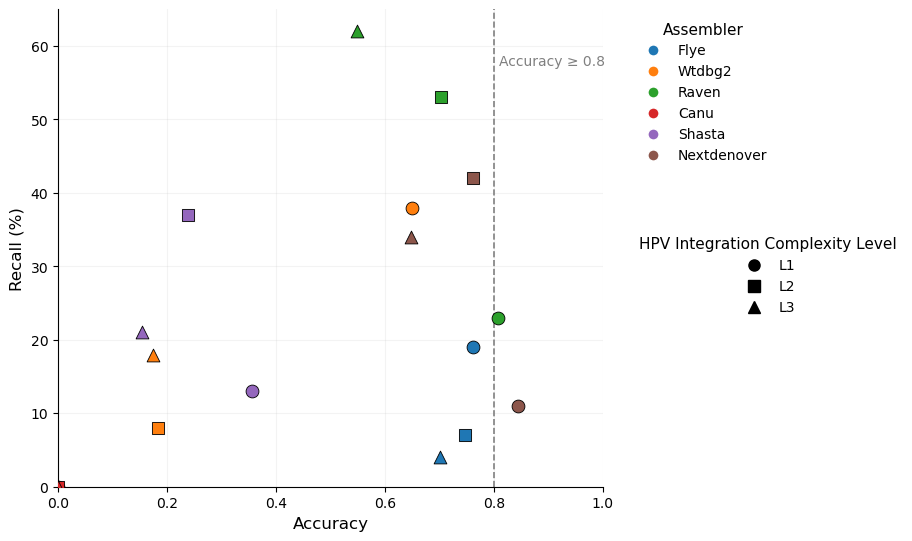

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
#######v2

# load data
df = pd.read_csv("/Users/ppxinyi/Documents/Assembly_review/30xL1-L3/Accurcy_recall_plot.csv")
df[["tool","level"]] = df["ID"].str.split("_", expand=True)
df["level"] = pd.Categorical(df["level"], categories=["l1","l2","l3"], ordered=True)

tools = list(df["tool"].unique())
colors = dict(zip(tools, plt.cm.tab10.colors[:len(tools)]))
marker_map = {"l1": "o", "l2": "s", "l3": "^"}

# --- Figure layout: main panel + legend panel ---
fig = plt.figure(figsize=(10.5, 6.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.45], wspace=0.06)
ax = fig.add_subplot(gs[0, 0])
ax_leg = fig.add_subplot(gs[0, 1])
ax_leg.axis("off")


for lv, mk in marker_map.items():
    sub = df[df["level"] == lv]
    ax.scatter(sub["Accuracy"], sub["Recall"],
               color="lightgray", marker=mk, s=95,
               edgecolor="white", linewidth=0.6, zorder=1)


for tool, sub in df.groupby("tool"):
    for _, row in sub.iterrows():
        ax.scatter(row["Accuracy"], row["Recall"],
                   color=colors[tool],
                   marker=marker_map[row["level"]],
                   s=85,
                   edgecolor="black", linewidth=0.6,
                   zorder=3)


thr = 0.8
ax.axvline(thr, linestyle="--", linewidth=1.2, color="gray", zorder=2)
ax.text(thr + 0.01,
        df["Recall"].max() * 0.95,
        "Accuracy ≥ 0.8",
        color="gray",
        fontsize=10,
        va="top")

ax.set_xlim(0, 1.0)
ymax = max(65, int(np.ceil(df["Recall"].max() / 5) * 5))
ax.set_ylim(0, ymax)

ax.set_xlabel("Accuracy", fontsize=12)
ax.set_ylabel("Recall (%)", fontsize=12)

ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_yticks(np.arange(0, ymax + 1, 10))

# --- 轻微网格 + 去掉上右边框 ---
ax.grid(alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Legends in side panel ---
tool_handles = [
    Line2D([0],[0], marker='o', color='w', label=tool,
           markerfacecolor=colors[tool], markersize=8)
    for tool in tools
]
level_handles = [
    Line2D([0],[0], marker=marker_map[l], color='black',
           linestyle='None', label=l.upper(), markersize=8)
    for l in ["l1","l2","l3"]
]

leg1 = ax_leg.legend(handles=tool_handles, title="Assembler",
                     loc="upper left", frameon=False,
                     fontsize=10, title_fontsize=11)
ax_leg.add_artist(leg1)

ax_leg.legend(handles=level_handles, title="HPV Integration Complexity Level",
              loc="upper left", bbox_to_anchor=(0, 0.55),
              frameon=False, fontsize=10, title_fontsize=11)


fig.savefig("/Users/ppxinyi/Documents/Assembly_review/30xL1-L3/main_figure/WGSAccuracy_Recall_main.pdf")             
# fig.savefig("Accuracy_Recall_main2.png", dpi=600)    

plt.show()